In [98]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
pd.options.display.max_columns= None

In [99]:
path= 'Loan_Default.csv'
data= pd.read_csv(path)
df= data.copy()

## EDA

+ missings
+ duplicates
+ data imbalance
+ matching-relations
+ outliers
+ rare labels

In [100]:
print(df.shape)
print('----------')
print(df.dtypes.value_counts())
print('----------')
print(df.isna().sum())

(148670, 34)
----------
object     21
float64     8
int64       5
Name: count, dtype: int64
----------
ID                               0
year                             0
loan_limit                    3344
Gender                           0
approv_in_adv                  908
loan_type                        0
loan_purpose                   134
Credit_Worthiness                0
open_credit                      0
business_or_commercial           0
loan_amount                      0
rate_of_interest             36439
Interest_rate_spread         36639
Upfront_charges              39642
term                            41
Neg_ammortization              121
interest_only                    0
lump_sum_payment                 0
property_value               15098
construction_type                0
occupancy_type                   0
Secured_by                       0
total_units                      0
income                        9150
credit_type                      0
Credit_Score          

<Axes: >

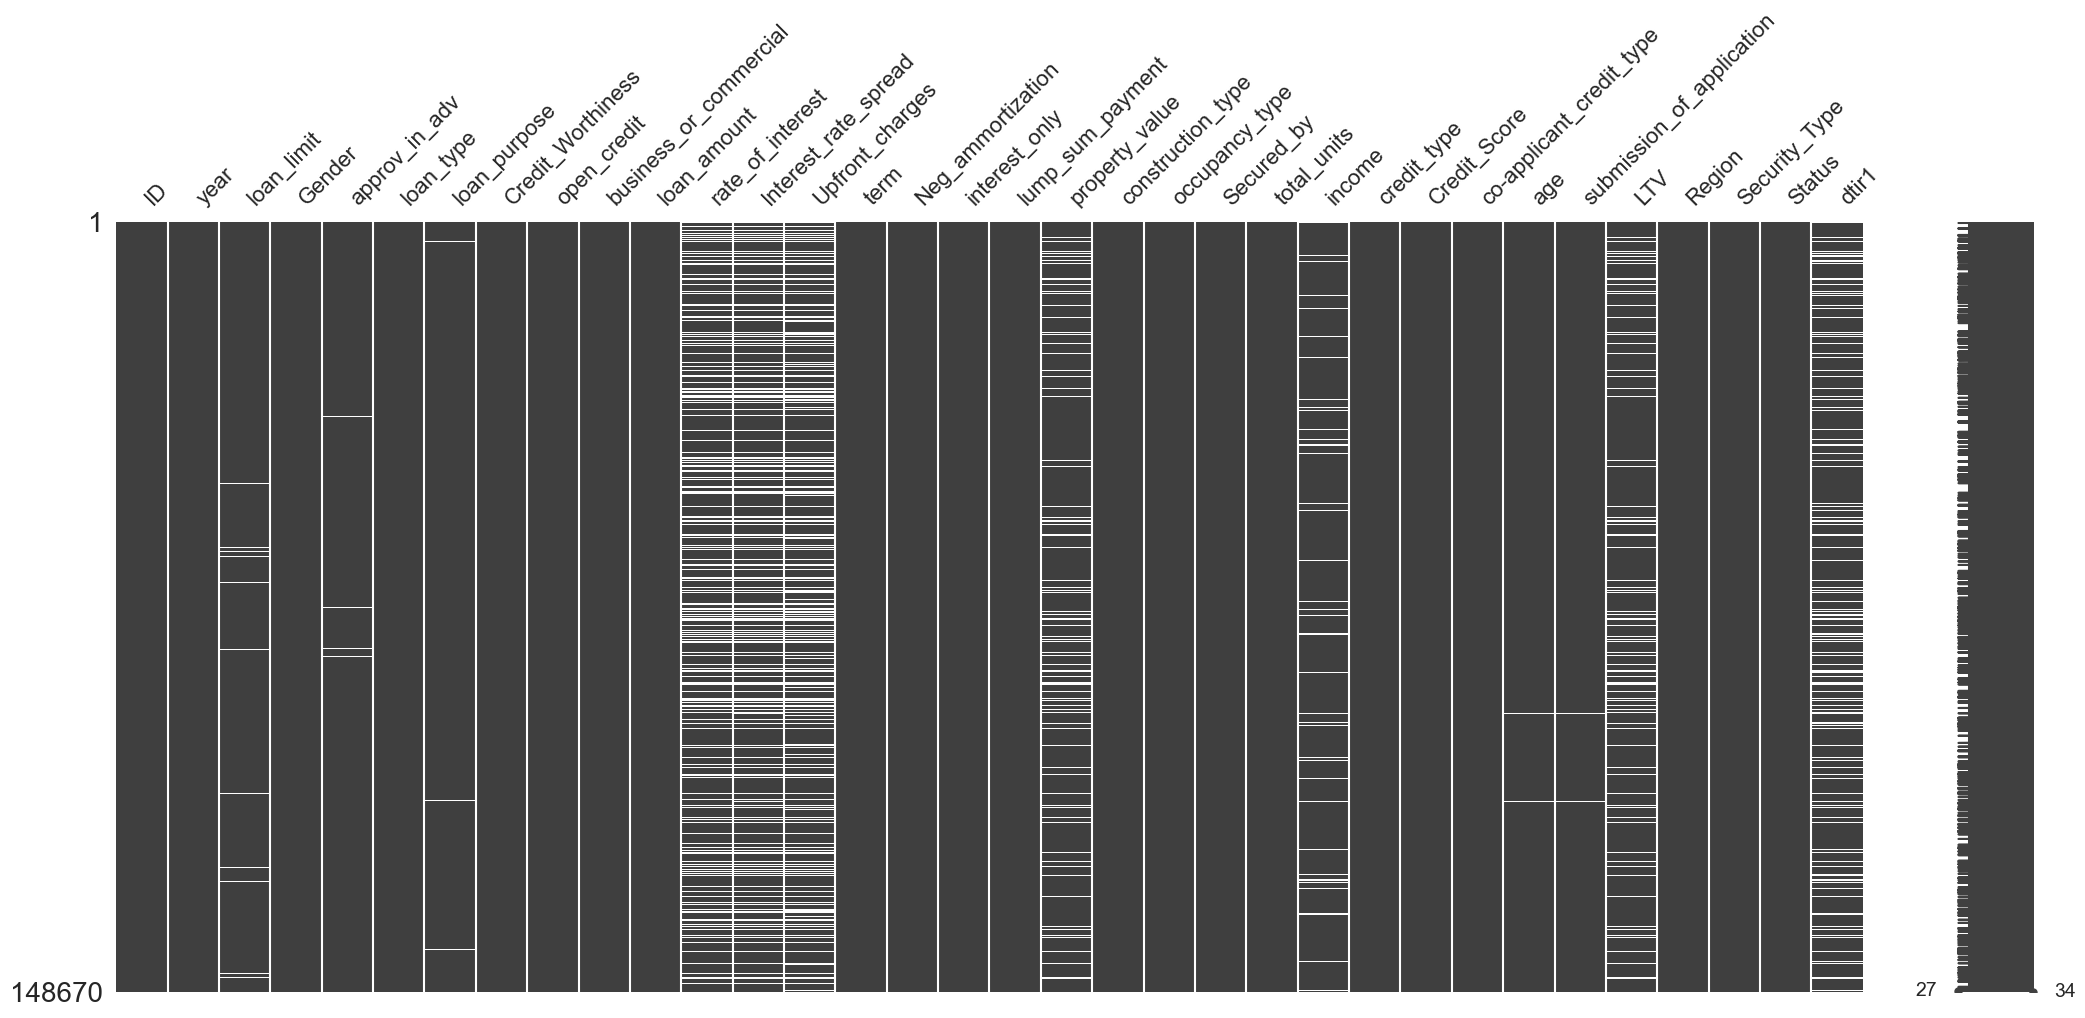

In [101]:
msno.matrix(df)

In [102]:
df.head(3)

,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,loan_amount,rate_of_interest,Interest_rate_spread,Upfront_charges,term,Neg_ammortization,interest_only,lump_sum_payment,property_value,construction_type,occupancy_type,Secured_by,total_units,income,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
0,24890,2019,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,116500,NaN,NaN,NaN,360.0,not_neg,not_int,not_lpsm,118000.0,sb,pr,home,1U,1740.0,EXP,758,CIB,25-34,to_inst,98.728814,south,direct,1,45.0
1,24891,2019,cf,Male,nopre,type2,p1,l1,nopc,b/c,206500,NaN,NaN,NaN,360.0,not_neg,not_int,lpsm,NaN,sb,pr,home,1U,4980.0,EQUI,552,EXP,55-64,to_inst,NaN,North,direct,1,NaN
2,24892,2019,cf,Male,pre,type1,p1,l1,nopc,nob/c,406500,4.56,0.2,595.0,360.0,neg_amm,not_int,not_lpsm,508000.0,sb,pr,home,1U,9480.0,EXP,834,CIB,35-44,to_inst,80.019685,south,direct,0,46.0


In [103]:
df.columns

Index(['ID', 'year', 'loan_limit', 'Gender', 'approv_in_adv', 'loan_type',
       'loan_purpose', 'Credit_Worthiness', 'open_credit',
       'business_or_commercial', 'loan_amount', 'rate_of_interest',
       'Interest_rate_spread', 'Upfront_charges', 'term', 'Neg_ammortization',
       'interest_only', 'lump_sum_payment', 'property_value',
       'construction_type', 'occupancy_type', 'Secured_by', 'total_units',
       'income', 'credit_type', 'Credit_Score', 'co-applicant_credit_type',
       'age', 'submission_of_application', 'LTV', 'Region', 'Security_Type',
       'Status', 'dtir1'],
      dtype='object')

In [104]:
#duplicates
print('Nb of duplicates:',df.duplicated().sum())
multiple_loans= df.duplicated(subset= ['Gender','income','Credit_Score','age','Region'])
print('Nb of ppl with multiple loans:',multiple_loans.sum())

Nb of duplicates: 0
Nb of ppl with multiple loans: 6578


In [105]:
from IPython.display import HTML

# Calculate statistics
counts = df['Status'].value_counts()
percents = df['Status'].value_counts(normalize=True) * 100

# Generate HTML table
html_table = "<table><tr><th>Status</th><th>Value Count</th><th>Percentage</th></tr>"
for index, value in counts.items():
    html_table += f"<tr><td>{index}</td><td>{value}</td><td>{percents[index]:.2f}%</td></tr>"
html_table += "</table>"

display(HTML(html_table))

Status,Value Count,Percentage
0,112031,75.36%
1,36639,24.64%


In [106]:
from IPython.display import HTML
import pandas as pd

# 1. Identify unique statuses to prevent "0%" mapping errors
unique_statuses = df['Status'].unique()

# 2. Get missing counts and sort
missing_data = df.isna().sum()
missing_data = missing_data[missing_data > 0].sort_values(ascending=False)

# 3. Create HTML with a dark-colored header (#2c3e50)
html = """<table style='width:100%; border-collapse: collapse; font-family: Arial, sans-serif;'>
<tr style='background-color: #2c3e50; color: white; text-align: left;'>
    <th style='padding: 12px;'>Feature</th>
    <th style='padding: 12px;'>NaN Count</th>
    <th style='padding: 12px;'>% Missing</th>"""

for s in unique_statuses:
    html += f"<th style='padding: 12px;'>% {s} (within NaN)</th>"
html += "</tr>"

# 4. Populate rows
for col, count in missing_data.items():
    pct_missing = (count / len(df)) * 100
    nan_subset_status = df[df[col].isna()]['Status']
    status_dist = nan_subset_status.value_counts(normalize=True) * 100
    
    html += f"<tr><td style='border-bottom: 1px solid #ddd; padding: 10px;'>{col}</td>"
    html += f"<td style='border-bottom: 1px solid #ddd; padding: 10px;'>{count}</td>"
    html += f"<td style='border-bottom: 1px solid #ddd; padding: 10px;'>{pct_missing:.2f}%</td>"
    
    for s in unique_statuses:
        val = status_dist.get(s, 0)
        html += f"<td style='border-bottom: 1px solid #ddd; padding: 10px;'>{val:.2f}%</td>"
    html += "</tr>"

html += "</table>"
display(HTML(html))


Feature,NaN Count,% Missing,% 1 (within NaN),% 0 (within NaN)
Upfront_charges,39642,26.66%,92.04%,7.96%
Interest_rate_spread,36639,24.64%,100.00%,0.00%
rate_of_interest,36439,24.51%,100.00%,0.00%
dtir1,24121,16.22%,67.62%,32.38%
property_value,15098,10.16%,99.99%,0.01%
LTV,15098,10.16%,99.99%,0.01%
income,9150,6.15%,13.54%,86.46%
loan_limit,3344,2.25%,26.35%,73.65%
approv_in_adv,908,0.61%,26.54%,73.46%
age,200,0.13%,100.00%,0.00%


In [107]:
print('unique ids:',len(df['ID'].unique()) == len(df)) # unique Ids
print('years recorded loans:', df['year'].unique())

unique ids: True
years recorded loans: [2019]


In [108]:
# 1. Filter for categorical (object) columns
cat_cols = df.select_dtypes(include=['object', 'category']).columns

html = """<table style='width:100%; border-collapse: collapse; font-family: sans-serif;'>
<tr style='background-color: #34495e; color: white;'>
    <th style='padding: 10px;'>Column</th>
    <th style='padding: 10px;'>Cardinality</th>
    <th style='padding: 10px;'>Value Distribution (Count & %)</th>
</tr>"""

for col in cat_cols:
    cardinality = df[col].nunique()
    counts = df[col].value_counts()
    percents = df[col].value_counts(normalize=True) * 100
    
    # Create a string for value distribution
    dist_str = "<br>".join([f"<b>{k}</b>: {v} ({percents[k]:.1f}%)" for k, v in counts.items()])
    
    html += f"<tr><td style='border: 1px solid #ddd; padding: 8px;'>{col}</td>"
    html += f"<td style='border: 1px solid #ddd; padding: 8px;'>{cardinality}</td>"
    html += f"<td style='border: 1px solid #ddd; padding: 8px;'>{dist_str}</td></tr>"

html += "</table>"
display(HTML(html))

Column,Cardinality,Value Distribution (Count & %)
loan_limit,2,cf: 135348 (93.1%)ncf: 9978 (6.9%)
Gender,4,Male: 42346 (28.5%)Joint: 41399 (27.8%)Sex Not Available: 37659 (25.3%)Female: 27266 (18.3%)
approv_in_adv,2,nopre: 124621 (84.3%)pre: 23141 (15.7%)
loan_type,3,type1: 113173 (76.1%)type2: 20762 (14.0%)type3: 14735 (9.9%)
loan_purpose,4,p3: 55934 (37.7%)p4: 54799 (36.9%)p1: 34529 (23.2%)p2: 3274 (2.2%)
Credit_Worthiness,2,l1: 142344 (95.7%)l2: 6326 (4.3%)
open_credit,2,nopc: 148114 (99.6%)opc: 556 (0.4%)
business_or_commercial,2,nob/c: 127908 (86.0%)b/c: 20762 (14.0%)
Neg_ammortization,2,not_neg: 133420 (89.8%)neg_amm: 15129 (10.2%)
interest_only,2,not_int: 141560 (95.2%)int_only: 7110 (4.8%)


In [109]:
iterative_drop_cols= ['loan_limit','Credit_Worthiness','open_credit','interest_only',
                      'lump_sum_payment','construction_type','occupancy_type','Secured_by',
                      'total_units','Security_Type', 'ID','year','Interest_rate_spread',
                      'Upfront_charges','credit_type']
#Upfront_charges/Interest_rate_spread are set after risk assessment, not viable for us
# id / year not predictive
# others are extremely imbalanced labels

In [110]:
# outliers:
df.select_dtypes(include= 'number').columns

Index(['ID', 'year', 'loan_amount', 'rate_of_interest', 'Interest_rate_spread',
       'Upfront_charges', 'term', 'property_value', 'income', 'Credit_Score',
       'LTV', 'Status', 'dtir1'],
      dtype='object')

In [111]:
counts = df['term'].value_counts()
total_len = len(df)

# 2. Identify the 'Default' label (Assumes 1 or 'Default')
# Adjust 'Default' if your label is different (e.g., 1)
default_val = 'Default' if 'Default' in df['Status'].unique() else 1

# 3. Build the Table
html = """<table style='width:100%; border-collapse: collapse; font-family: sans-serif;'>
<tr style='background-color: #8e44ad; color: white;'>
    <th style='padding: 10px;'>Term (Months)</th>
    <th style='padding: 10px;'>Frequency</th>
    <th style='padding: 10px;'>% of Total</th>
    <th style='padding: 10px;'>Default Rate (%)</th>
</tr>"""

for term, count in counts.items():
    pct_total = (count / total_len) * 100
    
    # Calculate % of defaults for this specific term
    subset = df[df['term'] == term]
    def_count = (subset['Status'] == default_val).sum()
    def_rate = (def_count / len(subset)) * 100
    
    html += f"<tr><td style='border: 1px solid #ddd; padding: 8px;'>{term}</td>"
    html += f"<td style='border: 1px solid #ddd; padding: 8px;'>{count}</td>"
    html += f"<td style='border: 1px solid #ddd; padding: 8px;'>{pct_total:.2f}%</td>"
    html += f"<td style='border: 1px solid #ddd; padding: 8px;'>{def_rate:.2f}%</td></tr>"

html += "</table>"
display(HTML(html))

Term (Months),Frequency,% of Total,Default Rate (%)
360.0,121685,81.85%,24.21%
180.0,12981,8.73%,24.30%
240.0,5859,3.94%,20.82%
300.0,2822,1.90%,56.56%
324.0,2766,1.86%,25.42%
120.0,510,0.34%,18.24%
144.0,263,0.18%,17.49%
348.0,260,0.17%,20.38%
336.0,213,0.14%,18.31%
96.0,194,0.13%,20.62%


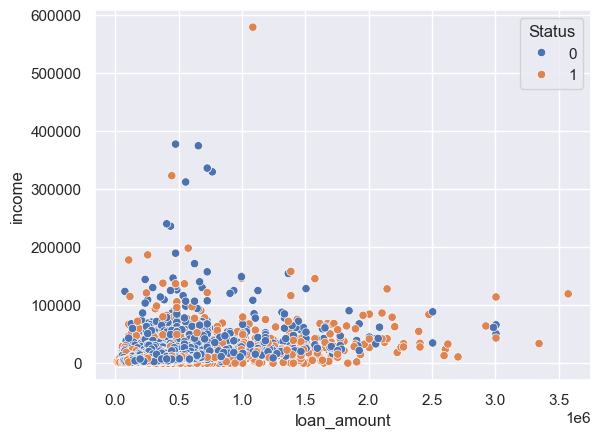

In [112]:
sns.set()
plt.figure()
sns.scatterplot(data= df, x='loan_amount',y='income', hue='Status')
plt.show()

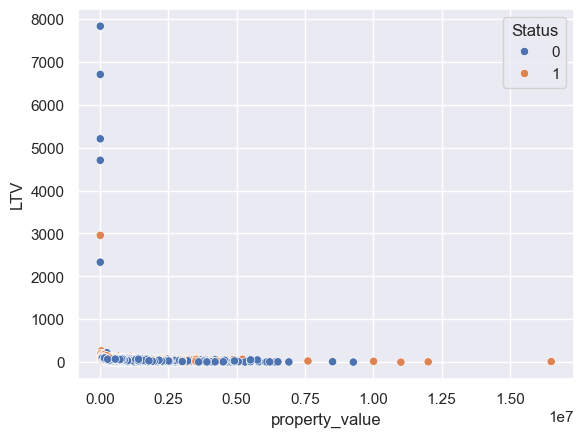

In [113]:
plt.figure()
sns.scatterplot(data= df, x= 'property_value', y='LTV', hue='Status')
plt.show()

In [114]:
df[['income','loan_amount','LTV','property_value']].describe().round(1)

,income,loan_amount,LTV,property_value
count,139520.0,148670.0,133572.0,133572.0
mean,6957.3,331117.7,72.7,497893.5
std,6496.6,183909.3,40.0,359935.3
min,0.0,16500.0,1.0,8000.0
25%,3720.0,196500.0,60.5,268000.0
50%,5760.0,296500.0,75.1,418000.0
75%,8520.0,436500.0,86.2,628000.0
max,578580.0,3576500.0,7831.2,16508000.0


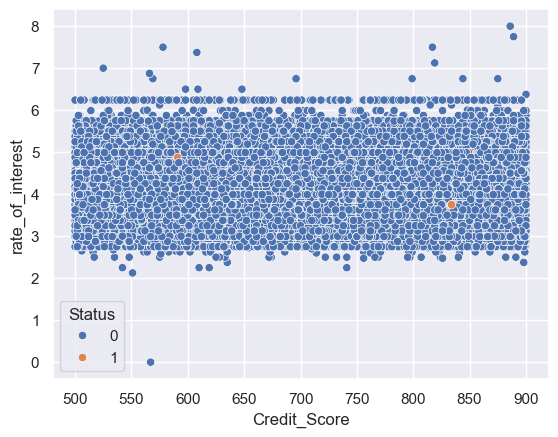

In [115]:
plt.figure()
sns.scatterplot(data= df, x='Credit_Score', y='rate_of_interest', hue='Status')
plt.show()

In [116]:
oi= []
oi.extend(df[df['income']> 200_000].index)
oi.extend(df[df['income']==0].index)
oi.extend(df[df['loan_amount']> 2_500_000].index)
oi.extend(df[df['LTV']>100].index)
oi.extend(df[df['property_value']>7_000_000].index)
oi.extend(df[df['rate_of_interest']==0].index)

## Feature Selection

+ Iterative Imputer
**removing-ouliters > filling nan**
+ IV ranking
+ VIF ranking
+ correlation matrix
+ Tree-Based importance
+ Domain knowledge

In [117]:
df= df.drop(iterative_drop_cols, axis= 1)
df =df.drop(list(set(oi)))
df.columns

Index(['Gender', 'approv_in_adv', 'loan_type', 'loan_purpose',
       'business_or_commercial', 'loan_amount', 'rate_of_interest', 'term',
       'Neg_ammortization', 'property_value', 'income', 'Credit_Score',
       'co-applicant_credit_type', 'age', 'submission_of_application', 'LTV',
       'Region', 'Status', 'dtir1'],
      dtype='object')

In [123]:
from sklearn.model_selection import train_test_split as tts
x_train, x_test, y_train, y_test= tts(df.drop('Status',axis= 1), df['Status'], test_size=.2, stratify= df['Status'])

In [124]:
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder
ohe_cols= ['Gender', 'approv_in_adv', 'loan_type', 'loan_purpose',
           'business_or_commercial','Neg_ammortization',
           'co-applicant_credit_type','submission_of_application','Region']
ore_cols= ['age']
age_order= ['<25','25-34', '35-44', '45-54','55-64', '65-74', '>74']
ore= OrdinalEncoder(categories= [age_order], handle_unknown='use_encoded_value',unknown_value=np.nan,
                    encoded_missing_value=np.nan)
ohe= OneHotEncoder(handle_unknown='ignore')
x_train[['age']]= ore.fit_transform(x_train[['age']])
ohe_output = ohe.fit_transform(x_train[ohe_cols])
new_cols = ohe.get_feature_names_out(ohe_cols)
ohe_df = pd.DataFrame(ohe_output.toarray(), columns=new_cols, index=x_train.index)
x_train = x_train.drop(columns=ohe_cols).join(ohe_df)
x_test[['age']] = ore.transform(x_test[['age']])
ohe_test_output = ohe.transform(x_test[ohe_cols])
ohe_test_df = pd.DataFrame(ohe_test_output.toarray(), columns=new_cols, index=x_test.index)
x_test = x_test.drop(columns=ohe_cols).join(ohe_test_df)

In [120]:
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor
iter_imp = IterativeImputer(
    estimator=RandomForestRegressor(n_estimators=10, max_depth=5, n_jobs=-1),
    max_iter=3,
    random_state=42
)
x_train_iter= iter_imp.fit_transform(x_train)
x_test_iter= iter_imp.transform(x_test)

c:\Users\mmopa\miniconda3\envs\ml\Lib\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


**simple xgboost to validate iterImpute**

In [121]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report as cr
from sklearn.impute import SimpleImputer
si= SimpleImputer(strategy= 'median')
x_train= si.fit_transform(x_train)
x_test= si.transform(x_test)
xgb_orig= XGBClassifier(class_weight= 'balanced')
xgb_iter= XGBClassifier(class_weight= 'balanced')
xgb_orig.fit(x_train, y_train)
xgb_iter.fit(x_train_iter, y_train)
print('ORIGINAL DATA')
print(cr(y_test, xgb_orig.predict(x_test)))
print('-----------------------')
print('Imputed DATA')
print(cr(y_test, xgb_iter.predict(x_test_iter)))

ORIGINAL DATA
              precision    recall  f1-score   support

           0       0.95      0.96      0.96     22276
           1       0.86      0.85      0.85      6841

    accuracy                           0.93     29117
   macro avg       0.91      0.90      0.90     29117
weighted avg       0.93      0.93      0.93     29117

-----------------------
Imputed DATA
              precision    recall  f1-score   support

           0       0.99      1.00      1.00     22276
           1       0.99      0.98      0.99      6841

    accuracy                           0.99     29117
   macro avg       0.99      0.99      0.99     29117
weighted avg       0.99      0.99      0.99     29117



**Our iterativeImputer did a good job, we'll transform the entire df dataframe now**

In [ ]:
# encode df, impute , unencode
# binning process calculate iv
# calculate vif, corr

,Gender,approv_in_adv,loan_type,loan_purpose,business_or_commercial,loan_amount,rate_of_interest,term,Neg_ammortization,property_value,income,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Status,dtir1
0,Sex Not Available,nopre,type1,p1,nob/c,116500,NaN,360.0,not_neg,118000.0,1740.0,758,CIB,25-34,to_inst,98.728814,south,1,45.0
1,Male,nopre,type2,p1,b/c,206500,NaN,360.0,not_neg,NaN,4980.0,552,EXP,55-64,to_inst,NaN,North,1,NaN


## Feature Engineering

In [ ]:
# engin feats, check iv vif corr of those only, remove one (important)
# pipeline the whole thing

## Preprocessing

In [ ]:
# binning process woe / pipeline it

## Model selection

## Model Tuning

## Model Evaluation

In [128]:
# learning / validation curve
# cmd /cr

## Model Adjusting

In [129]:
# calibration  & treshhold

## PD Model

In [131]:
# scorecard(pd) + points features

## EL Model

## Statistics

## PSI & CSI